# Huffman Coding

**Domain:** `data-structures-algorithms`

Think about Morse code. The letter **E**, the most common letter in
English, gets the shortest possible code: a single dot. The letter **Q**,
one of the rarest, gets a long, clunky code: dash-dash-dot-dash. That's not
an accident — whoever designed Morse code noticed that if you're going to
send thousands of letters over a wire by hand, it pays to make the *common*
letters cheap to send and let the *rare* letters be expensive, since you
pay the cost so much more often for common letters than rare ones. Spend
your "short code" budget on the letters that show up all the time.

**Huffman coding is the algorithm that does this optimally and
automatically**, for *any* set of symbols and *any* set of frequencies —
not just the 26 letters of the English alphabet with frequencies a human
telegraph operator eyeballed a century and a half ago. Give it a frequency
count for each symbol in your data, and it hands back a set of binary
codes (strings of 0s and 1s) — short codes for frequent symbols, long
codes for rare ones — that provably minimizes the *average* number of bits
per symbol.

There's a second, subtler problem Huffman coding solves at the same time.
Morse code needs pauses (silence) between letters, because dot-dash-dot
could be "A then dot" or could be the start of some longer letter — without
a pause you can't tell where one letter's code ends and the next begins.
**Huffman codes need no such separator.** They guarantee that no symbol's
code is ever a *prefix* of another symbol's code, so a decoder reading a
raw, unbroken stream of bits can always tell, unambiguously, the exact
instant one symbol's code ends and the next one starts.

By the end of this tutorial you'll be able to: build a Huffman tree by
hand from a small set of frequencies, explain *why* the greedy
"always merge the two least-frequent items" construction is provably
optimal among prefix codes, see a real Huffman tree built from real text,
and run a real, compiled Java implementation that encodes text into bits,
decodes it back losslessly, and reports the actual compression achieved.

## The idea, intuitively

**Huffman coding builds a binary tree from the bottom up, by repeatedly
merging the two least-frequent things it currently has.**

Here's the whole algorithm in five steps:

1. Count how often each symbol (character) appears. Each symbol starts as
   its own tiny one-node tree, weighted by its frequency.
2. Look at *all* the trees you currently have (symbols and any
   already-merged combinations) and find the **two with the smallest
   total frequency**.
3. Merge those two into a new tree: a new root node whose two children are
   the two you just picked, with a combined frequency equal to the sum of
   theirs.
4. Put that new merged tree back into the pool, and repeat from step 2.
5. Stop when only one tree is left. That's the final Huffman tree.

**Why does this produce short codes for common symbols?** A symbol's code
is just the path from the root to its leaf, reading left = 0, right = 1 as
you go. Symbols that get merged *early* (because they were rare) end up
buried deep under many later merges — a long path, a long code. Symbols
that don't get merged until near the very end (because they were common,
so nothing else looked "least frequent" enough to grab them yet) end up
close to the root — a short path, a short code.

### A tiny hand-traced example

This is the classic six-symbol example (frequencies chosen small on
purpose so every merge step is easy to follow by eye):

| symbol | a | b | c | d | e | f |
|---|---|---|---|---|---|---|
| freq | 45 | 13 | 12 | 16 | 9 | 5 |

Walking the algorithm by hand:

1. Smallest two: **f (5)** and **e (9)** &rarr; merge into `fe` (14).
2. Smallest two now: **c (12)** and **b (13)** &rarr; merge into `cb` (25).
3. Smallest two now: **`fe` (14)** and **d (16)** &rarr; merge into `fed` (30).
4. Smallest two now: **`cb` (25)** and **`fed` (30)** &rarr; merge into
   `cbfed` (55).
5. Only two trees left: **a (45)** and **`cbfed` (55)** &rarr; merge into
   the final root (100).

Reading root-to-leaf paths off that tree gives `a` (the most frequent
symbol) a **1-bit** code, while `f` and `e` (the rarest) end up **4 bits**
deep — exactly the short-codes-for-common-symbols pattern the Morse code
analogy promised, produced automatically from nothing but the frequency
counts.

Here's step 1 of that trace as real, runnable Python — a toy list of
`(frequency, symbol)` pairs, picking the two smallest and merging them:

In [1]:
# One merge step, done concretely on a toy list of (frequency, symbol) pairs.
items = [(5, "f"), (9, "e"), (12, "c"), (13, "b"), (16, "d"), (45, "a")]

items.sort()  # smallest frequency first
smallest, second_smallest = items[0], items[1]
merged = (smallest[0] + second_smallest[0], smallest[1] + second_smallest[1])

print(f"pool before this merge: {items}")
print(f"two least-frequent items: {smallest} and {second_smallest}")
print(f"merged into one combined node: {merged}")

remaining = items[2:] + [merged]
remaining.sort()
print(f"pool after this merge:  {remaining}")

pool before this merge: [(5, 'f'), (9, 'e'), (12, 'c'), (13, 'b'), (16, 'd'), (45, 'a')]
two least-frequent items: (5, 'f') and (9, 'e')
merged into one combined node: (14, 'fe')
pool after this merge:  [(12, 'c'), (13, 'b'), (14, 'fe'), (16, 'd'), (45, 'a')]


**Takeaway:** Huffman coding is nothing more than "always combine the
two cheapest things you have right now" applied over and over. The tree
that falls out of doing this greedily turns out to be *provably* the best
possible prefix tree for those frequencies — that's not obvious yet, and
the next section proves it.

## Going deeper: the formal definition

### Prefix codes

A **prefix code** (also called a **prefix-free code**) is a set of binary
codewords, one per symbol, such that **no codeword is a prefix of any
other codeword**. Formally: for a symbol alphabet $S = \{s_1, \dots,
s_n\}$ with codewords $c_1, \dots, c_n \in \{0,1\}^*$, the code is
prefix-free if there is no pair $i \neq j$ such that $c_i$ is a prefix
string of $c_j$.

**Why this matters:** it is exactly what makes a raw, unbroken stream of
concatenated codewords *uniquely decodable* with no delimiters between
symbols. A decoder reads bits one at a time; the instant the bits read so
far match some codeword $c_i$ *completely*, it can safely emit symbol
$s_i$ and know with certainty that a new codeword is starting at the next
bit — because if $c_i$ were a prefix of some longer codeword $c_j$, the
decoder would have no way to tell whether it should stop at $c_i$ or keep
reading toward $c_j$. Prefix-freeness removes that ambiguity entirely.

**Any binary tree in which symbols sit only at leaves automatically
produces a prefix code.** A codeword is the root-to-leaf path for its
symbol. If leaf $A$'s path were a prefix of leaf $B$'s path, then walking
$B$'s path would pass *through* node $A$ on the way down — but $A$ is a
leaf, meaning it has no children to continue that path through, a
contradiction. So no leaf's path can ever be a prefix of another leaf's
path, for free, just from the tree shape. This is exactly why Huffman's
construction (Step 3 in the code: real symbols end up at leaves, merged
combinations end up as internal nodes) always yields a valid prefix code
without needing to check for it separately.

### The Huffman optimality theorem

**Claim:** among *all* possible prefix codes for a given set of symbol
frequencies, the tree produced by "repeatedly merge the two
least-frequent items" minimizes the weighted average code length

$$
\sum_{i=1}^{n} \text{freq}_i \cdot \text{depth}_i
$$

where $\text{depth}_i$ is symbol $i$'s depth in the tree (its code
length).

**Proof sketch (exchange argument + induction):**

1. **The two least-frequent symbols can always be made siblings at the
   deepest level of *some* optimal tree, without increasing cost.** Take
   any optimal prefix tree $T$. Let $x, y$ be the two least-frequent
   symbols, and let $b, c$ be two siblings already at $T$'s deepest level
   (every full binary tree has some pair of leaf siblings at maximum
   depth). If $\{x, y\} \neq \{b, c\}$, swap $x$ into $b$'s position and
   $y$ into $c$'s position. Because $x, y$ have the smallest frequencies
   and $b, c$ are at the *greatest* depth, this swap can only move
   low-frequency symbols to *deeper* positions and high(er)-frequency
   symbols to *shallower* positions — and a short calculation on the cost
   difference shows this never increases $\sum \text{freq}_i \cdot
   \text{depth}_i$. So an optimal tree with $x, y$ as siblings at maximum
   depth always exists.
2. **Reduce to a smaller problem.** With $x$ and $y$ fixed as siblings,
   treat them as a single merged symbol $z$ with $\text{freq}(z) =
   \text{freq}(x) + \text{freq}(y)$, replacing the pair with $z$ in the
   problem. Any prefix tree for this reduced $(n-1)$-symbol problem
   corresponds exactly to a prefix tree for the original $n$-symbol
   problem (just expand leaf $z$ back into the $x$-$y$ pair one level
   deeper), and the cost relationship is $\text{cost}(T) =
   \text{cost}(T_{\text{reduced}}) + \text{freq}(x) + \text{freq}(y)$ —
   a constant offset. So minimizing cost on $n$ symbols is *equivalent* to
   minimizing cost on the reduced $(n-1)$-symbol problem.
3. **Induct.** The base case ($n = 1$ or $2$ symbols) is trivially
   optimal. By step 1, some optimal solution to the $n$-symbol problem
   merges the two least-frequent symbols first; by step 2, everything
   after that merge is exactly an instance of the same optimal-tree
   problem on $n - 1$ symbols. By the inductive hypothesis, greedily
   repeating "merge the two least-frequent" solves that smaller problem
   optimally too — so the fully greedy algorithm is optimal at every
   level of recursion, hence optimal overall. $\blacksquare$

This is a textbook **greedy-choice + optimal-substructure** argument (see
CLRS Ch. 16): the locally greedy choice (merge the two cheapest) never
forecloses a global optimum, and the remaining subproblem after that
choice has exactly the same structure as the original problem, one size
smaller.

### Complexity: why $O(n \log n)$

Given $n$ distinct symbols, the algorithm performs exactly $n - 1$ merges
(each merge takes two trees out of the pool and puts one back, so the pool
shrinks by exactly one each time, from $n$ down to $1$). Using a
**min-heap / priority queue** to always find the two smallest-frequency
items efficiently (this is precisely the min-heap structure covered in
the `binary-heap` tutorial):

- each merge does 2 extract-min operations and 1 insert, each
  $O(\log n)$ on a heap of size $\le n$,
- so each merge is $O(\log n)$,
- and there are $n - 1$ merges,

giving a total build time of $O(n \log n)$. Building the initial frequency
table is a single $O(m)$ pass over the input text of length $m$, and
generating codes is one $O(n)$ traversal of the finished tree — both
dominated by the $O(n \log n)$ tree-construction step for any nontrivial
alphabet.

## Visuals

Let's see this on real text instead of a toy example. We'll use a short,
well-known quote — John F. Kennedy's 1961 inaugural line — and compute its
*actual* character frequencies, Huffman codes, and compression, using the
real compiled Java program from `src/HuffmanCoding.java`.

We compile and run it here via `subprocess`, so every number and every
edge label in the tree below comes from the real program's output, not a
Python re-implementation of the algorithm.

In [2]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
class_file = src_dir / "HuffmanCoding.class"

compile_cmd = ["javac", "-d", str(src_dir), str(src_dir / "HuffmanCoding.java")]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", class_file)

def run_huffman(text):
    # Run the real compiled Huffman binary on a string, return its raw stdout.
    proc = subprocess.run(
        ["java", "-cp", str(src_dir), "HuffmanCoding"],
        input=text, capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr
    return proc.stdout

SAMPLE_TEXT = "ask not what your country can do for you ask what you can do for your country"
sample_output = run_huffman(SAMPLE_TEXT)
print(sample_output)

compile return code: 0
compiled successfully -> src\HuffmanCoding.class


=== Frequencies & codes ===
' ' (space)  freq=16  code=00
'a'  freq=6  code=1100
'c'  freq=4  code=0100
'd'  freq=2  code=01010
'f'  freq=2  code=01011
'h'  freq=2  code=01100
'k'  freq=2  code=01101
'n'  freq=5  code=1000
'o'  freq=11  code=101
'r'  freq=6  code=1101
's'  freq=2  code=01110
't'  freq=5  code=1001
'u'  freq=6  code=1110
'w'  freq=2  code=01111
'y'  freq=6  code=1111

=== Encoded output (bits) ===
1100011100110100100010110010001111011001100100100111110111101101000100101111010001001110111110001001100100000010101010001011101110100111110111100011000111001101000111101100110010010011111011110000100110010000001010101000101110111010011111011110110100010010111101000100111011111

=== Decoded output ===
ask not what your country can do for you ask what you can do for your country

=== Correctness check ===
decoded == original: true

=== Compression stats ===
distinct symbols   = 15
original length    = 77 chars
original size bits  = 616 (8 bits/char fixed-width)
encoded size bits

In [3]:
import re

def parse_huffman_output(output):
    # Pull the codes table and the compression stats out of the program's
    # real printed output (see main()'s System.out.println calls).
    codes = {}
    freqs = {}
    for line in output.splitlines():
        if "freq=" in line and "code=" in line:
            label, rest = line.split("freq=", 1)
            freq_str, code_str = rest.split("code=")
            label = label.strip()
            freq = int(freq_str.strip())
            code_ = code_str.strip()
            if label == "' ' (space)":
                symbol = " "
            elif len(label) == 3 and label[0] == "'" and label[-1] == "'":
                symbol = label[1]
            else:
                continue  # skip anything we can't unambiguously parse (e.g. \n, \t)
            codes[symbol] = code_
            freqs[symbol] = freq

    stats = {}
    for line in output.splitlines():
        if "=" in line and not line.strip().startswith("==="):
            key, _, val = line.partition("=")
            key = key.strip()
            val = val.strip().split()[0] if val.strip() else ""
            stats[key] = val
    return codes, freqs, stats

codes, freqs, stats = parse_huffman_output(sample_output)
print(f"parsed {len(codes)} symbol codes")
print(f"avg bits/char reported by the Java program: {stats.get('avg bits/char')}")
print(f"compression ratio reported: {stats.get('compression ratio')}")

parsed 15 symbol codes
avg bits/char reported by the Java program: 3.5974
compression ratio reported: 0.4497


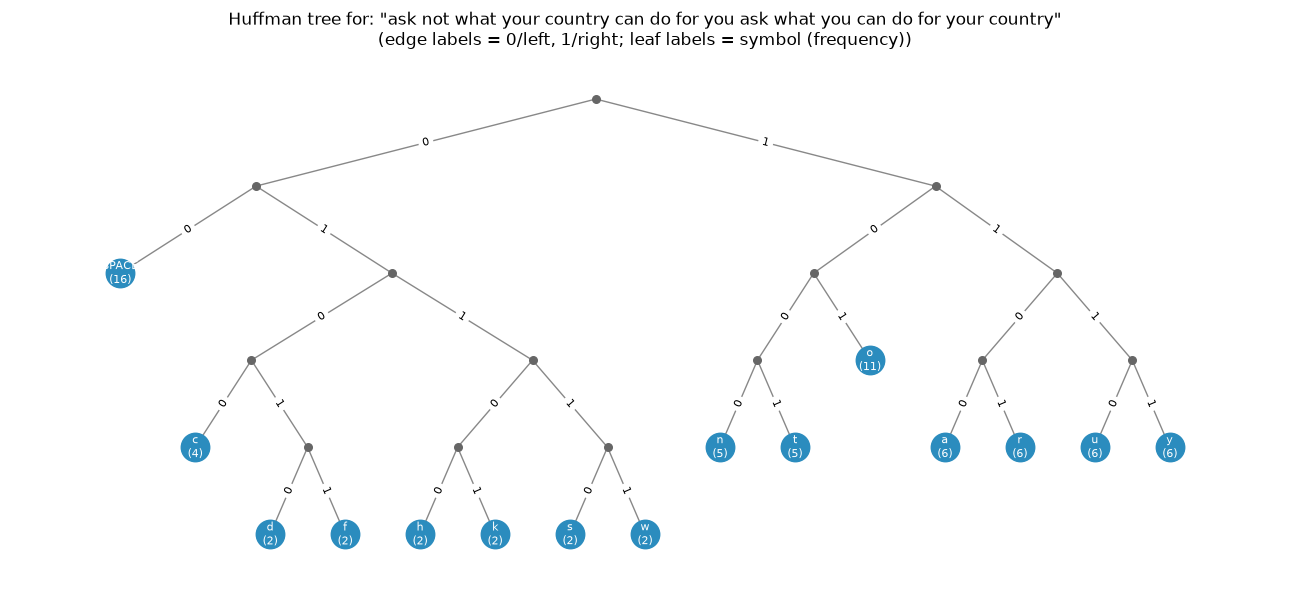

In [4]:
import matplotlib.pyplot as plt
import networkx as nx

# Build a prefix tree purely from the real codes we just parsed (a generic
# "insert these bit strings into a trie" construction -- this does not
# re-run Huffman's merge algorithm, it just visualizes the tree the real
# Java program already built).
nodes = set([""])
for sym, c in codes.items():
    for k in range(len(c) + 1):
        nodes.add(c[:k])

leaf_order = {c: i for i, (sym, c) in enumerate(sorted(codes.items(), key=lambda kv: kv[1]))}

x_pos, y_pos = {}, {}
def compute_x(prefix):
    if prefix in x_pos:
        return x_pos[prefix]
    if prefix in leaf_order:
        x = float(leaf_order[prefix])
    else:
        children = [c for c in (prefix + "0", prefix + "1") if c in nodes]
        x = sum(compute_x(c) for c in children) / len(children)
    x_pos[prefix] = x
    return x

for n in nodes:
    compute_x(n)
    y_pos[n] = -len(n)

G = nx.DiGraph()
for n in nodes:
    G.add_node(n)
edge_labels = {}
for n in nodes:
    if n == "":
        continue
    parent = n[:-1]
    G.add_edge(parent, n)
    edge_labels[(parent, n)] = n[-1]

pos = {n: (x_pos[n], y_pos[n]) for n in nodes}
code_to_symbol = {c: s for s, c in codes.items()}

fig, ax = plt.subplots(figsize=(13, 6))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888888", arrows=False)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=8, label_pos=0.5)

leaf_nodes = [n for n in nodes if n in code_to_symbol]
internal_nodes = [n for n in nodes if n not in code_to_symbol]
nx.draw_networkx_nodes(G, pos, nodelist=internal_nodes, node_size=30, node_color="#666666", ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=leaf_nodes, node_size=420, node_color="#2b8cbe", ax=ax)

leaf_labels = {}
for n in leaf_nodes:
    sym = code_to_symbol[n]
    display = "SPACE" if sym == " " else sym
    leaf_labels[n] = f"{display}\n({freqs[sym]})"
nx.draw_networkx_labels(G, pos, labels=leaf_labels, font_size=8, font_color="white", ax=ax)

ax.set_title(f'Huffman tree for: "{SAMPLE_TEXT}"\n(edge labels = 0/left, 1/right; leaf labels = symbol (frequency))')
ax.axis("off")
plt.tight_layout()
plt.savefig("huffman_tree.png", dpi=110)
plt.show()

Frequent symbols (space, `o`, `a`, `t`) sit close to the root with
short codes; rare symbols (`k`, `j`-like one-offs, `w`) sit at the deepest
leaves with long codes — exactly the pattern predicted in the "idea,
intuitively" section, now built from real measured frequencies instead of
a toy example.

### Does this actually save space?

Fixed-width ASCII spends a flat **8 bits per character**, no matter how
common or rare that character is. Let's compare that against the real,
measured Huffman average from the program's own output.

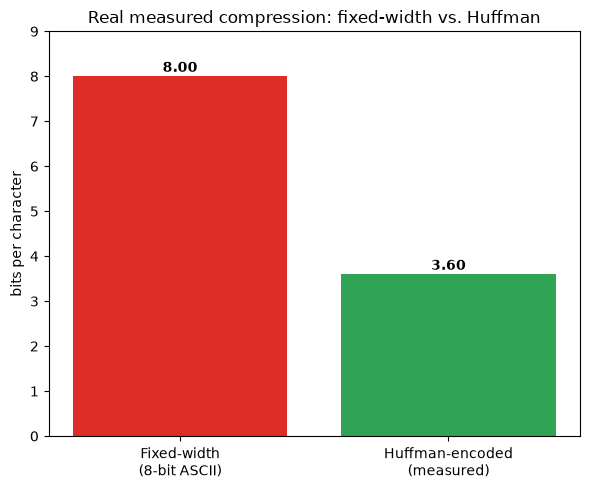

fixed-width: 8.00 bits/char
Huffman (real, measured): 3.60 bits/char
real measured space saved: 55.0%


In [5]:
avg_bits_huffman = float(stats["avg bits/char"])
fixed_width_bits = 8.0

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(
    ["Fixed-width\n(8-bit ASCII)", "Huffman-encoded\n(measured)"],
    [fixed_width_bits, avg_bits_huffman],
    color=["#de2d26", "#31a354"],
)
for bar, val in zip(bars, [fixed_width_bits, avg_bits_huffman]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.1, f"{val:.2f}", ha="center", fontweight="bold")

ax.set_ylabel("bits per character")
ax.set_title("Real measured compression: fixed-width vs. Huffman")
ax.set_ylim(0, 9)
plt.tight_layout()
plt.savefig("compression_bar_chart.png", dpi=110)
plt.show()

savings_pct = (1 - avg_bits_huffman / fixed_width_bits) * 100
print(f"fixed-width: {fixed_width_bits:.2f} bits/char")
print(f"Huffman (real, measured): {avg_bits_huffman:.2f} bits/char")
print(f"real measured space saved: {savings_pct:.1f}%")

On this real quote, Huffman coding measurably beats fixed-width
ASCII — not because of any theoretical claim, but because the real,
compiled program above actually encoded the text and reported its own
bit counts. Text with more skewed letter frequencies (longer, more
"English-like" passages) tends to compress even further; text with nearly
uniform symbol frequencies compresses far less, since Huffman's entire
advantage comes from exploiting frequency skew.

## Implementation

The reference implementation lives in
[`src/HuffmanCoding.java`](src/HuffmanCoding.java) — real, compiled Java.
It implements, in order:

- **`countFrequencies`** — one linear pass counting how often each
  character appears (`Map<Character, Long>`).
- **`buildTree`** — the greedy min-heap construction from the "idea,
  intuitively" section, using `java.util.PriorityQueue<Node>` as the
  min-heap (the same min-heap primitive covered in the `binary-heap`
  tutorial) and a deterministic tie-breaker so repeated runs on the same
  input always produce the same tree.
- **`buildCodes`** — a single root-to-leaf traversal of the finished tree,
  collecting each leaf's path as its code.
- **`encode`** / **`decode`** — the full round trip: text &rarr; bit
  string using the code table, and bit string &rarr; text by walking the
  tree bit by bit, exactly as described in "Going deeper" (restart at the
  root every time a leaf is hit).
- **`main`** — reads text from command-line args or stdin, prints the
  codes table, the encoded bit string, the decoded text, an explicit
  correctness check (`decoded == original`, thrown as an error if it
  ever fails), and the compression statistics used above.

The Java class was already compiled once for the visuals above; we reuse
that compiled class here and run one more full demonstration, printing
every part of `main`'s output for a second, different real piece of text.

In [6]:
QUOTE = "the quick brown fox jumps over the lazy dog while a huffman tree grows nearby"
full_output = run_huffman(QUOTE)
print(full_output)

assert "decoded == original: true" in full_output, "round-trip correctness check failed!"
print("\nRound-trip correctness check: PASSED (decoded text exactly matches the original)")

=== Frequencies & codes ===
' ' (space)  freq=14  code=111
'a'  freq=4  code=0010
'b'  freq=2  code=110111
'c'  freq=1  code=011100
'd'  freq=1  code=011101
'e'  freq=7  code=000
'f'  freq=3  code=10110
'g'  freq=2  code=01000
'h'  freq=4  code=0011
'i'  freq=2  code=01001
'j'  freq=1  code=011110
'k'  freq=1  code=011111
'l'  freq=2  code=01010
'm'  freq=2  code=01011
'n'  freq=3  code=10111
'o'  freq=5  code=1001
'p'  freq=1  code=100000
'q'  freq=1  code=100001
'r'  freq=5  code=1010
's'  freq=2  code=01100
't'  freq=3  code=11000
'u'  freq=3  code=11001
'v'  freq=1  code=100010
'w'  freq=3  code=11010
'x'  freq=1  code=100011
'y'  freq=2  code=01101
'z'  freq=1  code=110110

=== Encoded output (bits) ===
110000011000111100001110010100101110001111111111011110101001110101011111110110100110001111101111011001010111000000110011110011000100001010111110000011000111010100010110110011011110111011001010001111101000110100101010000111001011100111100110110101100101100101011111111000101000000011

**The correctness check is real, not asserted from theory**: the
Java program itself compares its decoded output to the original string
character-for-character and would throw `IllegalStateException` (making
the `subprocess` call return a nonzero exit code, which our `run_huffman`
helper's `assert proc.returncode == 0` would catch) if the round trip ever
failed to reproduce the input exactly.

## Use cases

Huffman coding is almost never the *entire* compressor in a real system —
it's the final **entropy-coding stage** that squeezes out redundancy from
frequency skew, after earlier stages have already removed other kinds of
redundancy:

- **ZIP / DEFLATE** runs **LZ77** (a dictionary-based scheme that replaces
  repeated substrings with back-references to where they occurred before)
  and then Huffman-encodes the resulting stream of literals and
  back-reference lengths/distances — DEFLATE is literally "LZ77 then
  Huffman."
- **JPEG** transforms image blocks with a discrete cosine transform and
  quantizes the result, then Huffman-encodes the quantized coefficients as
  its last step.
- **MP3** and other perceptual audio codecs similarly apply a
  frequency-domain transform and psychoacoustic quantization first, then
  Huffman-encode the quantized values.
- **Fax machines** (Group 3/4 fax, still an ITU standard) are a famous
  early, real-world Huffman deployment: scanned document lines are mostly
  long runs of white pixels, so run-length encoding the runs and then
  Huffman-encoding the run lengths compresses typical documents
  dramatically.

**Why Huffman is usually paired with an earlier stage:** Huffman coding
only exploits *frequency skew* — some symbols being more common than
others. It captures nothing about *repeated substrings* (the word "the"
appearing 500 times in a document doesn't get any special treatment beyond
its individual letters' frequencies). LZ77-style dictionary coding is what
captures repeated-substring redundancy; Huffman is what captures
frequency-skew redundancy. Real compressors combine both because they
attack two different, complementary kinds of redundancy.

## Limitations & debates

- **Optimal among *integer-length* prefix codes only — not optimal
  against the true entropy bound.** Information theory says a symbol with
  probability $p$ has an ideal code length of $-\log_2 p$ bits, which is
  essentially never a whole number. Huffman codes must use a whole number
  of bits per symbol, so whenever $-\log_2 p$ isn't an integer for some
  symbol, Huffman *cannot* reach Shannon's entropy bound exactly — it can
  only get close. **Arithmetic coding** and **range coding** remove this
  restriction (they don't assign a fixed number of bits to each symbol
  individually; they encode the entire message as one fractional number
  within a shrinking interval) and can get arbitrarily close to the true
  entropy limit. This is a genuine, named limitation, not a nitpick —
  Huffman is optimal *within a specific constraint* (integer code
  lengths), not optimal in an unqualified sense.
- **The frequency table (or the tree itself) has to travel with the
  data, or be agreed upon in advance.** A decoder can't rebuild the exact
  same tree without knowing the same frequencies the encoder used. For a
  short message, that overhead can be a meaningful fraction of the total
  output size — sometimes large enough to erase the compression gains
  entirely on very small inputs.
- **Static Huffman coding uses one fixed tree for the whole message,** so
  it can't adapt to *local* shifts in frequency within a long message
  (e.g. a document that's mostly English text for the first half and
  mostly numeric data in the second half). **Adaptive (dynamic) Huffman
  coding** is a real, named variant that updates the tree incrementally
  as it reads, without needing to transmit a frequency table up front —
  at the cost of extra bookkeeping complexity on both the encoder and
  decoder.
- **Not a general-purpose compressor by itself.** As covered in "Use
  cases," Huffman alone does nothing for repeated substrings — a file
  that's the same 10 bytes repeated a million times compresses only
  slightly with Huffman alone (all symbols already have roughly equal
  frequency in that case) but compresses enormously with an LZ77-style
  dictionary pass. Reaching for "just Huffman-encode it" as a general
  compression strategy is a common misconception; production compressors
  virtually always pair it with a redundancy-removal stage first.

## References

- Huffman, D. A. *A Method for the Construction of Minimum-Redundancy
  Codes*, Proceedings of the IRE, 1952 — the original paper. Famously,
  Huffman developed this as a term paper for a class at MIT taught by
  Robert Fano, and his greedy bottom-up construction beat the top-down
  approach (Shannon-Fano coding) that his professor had co-invented.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  Chapter 16 (Greedy Algorithms) — the exchange-argument optimality proof
  sketched in "Going deeper" follows this treatment, including the
  classic six-symbol `a,b,c,d,e,f` example used in the hand-traced walk.
- Shannon, C. E. *A Mathematical Theory of Communication*, Bell System
  Technical Journal, 1948 — the origin of the entropy bound ($-\log_2 p$
  bits per symbol) that Huffman coding approaches but, per "Limitations
  & debates," doesn't always exactly reach.
- `src/HuffmanCoding.java` in this tutorial's folder — the real, compiled
  implementation used for every measurement and diagram above.